# Point of View (POV) Video Analysis

```
STUDENT: Jonathan Alexander Chiriboga Guallpa
NEPTUN CODE: DW8WI8
```


In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from jedi.inference.cache import inference_state_method_generator_cache

## Utility Functions
This sections only contains functions relative to common uses.

In [18]:
#=================UTILITY FUNCTIONS======================
def show_single_image(img, title: str, grid: str = 'off'):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,10))
    plt.title(title)
    plt.axis(grid)
    plt.imshow(img)
    plt.show()

def get_video_metadata(video_path: str) -> pd.DataFrame:
    video = cv2.VideoCapture('../data/input/GH017914.MP4')
    metadata = {
        'fps': video.get(cv2.CAP_PROP_FPS),
        'width': int(video.get(cv2.CAP_PROP_FRAME_WIDTH)),
        'height': int (video.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    return pd.DataFrame([metadata])

## Preliminary Image Analysis
This sections is oriented to present an evaluation frame per frame. This approach was considered for experimental uses, the next step is work using the full
videos sequences.

### Camera Initial information

1. Camera Model: GoPro 7
2. Image size: 1920 x 1080 (width x height)
3. Image Frame Rate: 29.97 fps

**At the end of this section you will find the main conclusions.**

In [15]:
#==============================VIDEO METADATA===========================
video_path = '../data/input/GH017914.MP4'
video_metadata = get_video_metadata(video_path)
video_metadata


,fps,width,height
0,29.97003,1920,1080


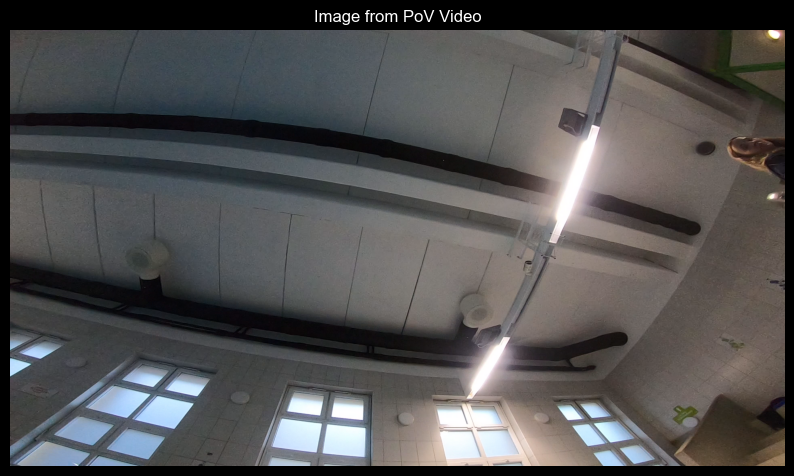

In [54]:
img_base = cv2.imread('../data/frames_v1/frame_0004.png', cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH | cv2.IMREAD_IGNORE_ORIENTATION)
show_single_image(img_base, 'Image from PoV Video')

### Image Radial Distortion Analysis

Prior to implementing the optical flow algorithm, a geometric analysis was conducted. The most prominent artifact identified was radial distortion. To demonstrate this effect, two reference lines were superimposed, using linear structural elements—specifically the black conduit and the white beam—as ground-truth benchmarks.

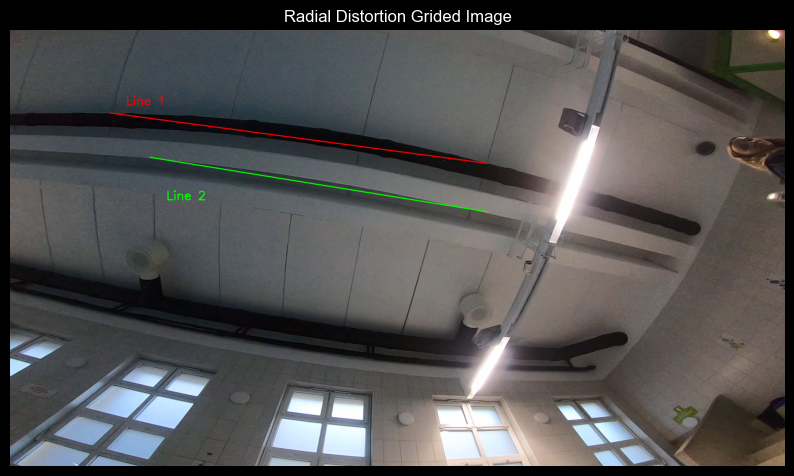

In [62]:
#Showing image distortions
def draw_guid_grid(img, width, height):
    cop_img = img.copy()
    l1_start, l1_end = (247, 205), (1183, 330)
    l2_start, l2_end = (347, 315), (1183, 450)

    cv2.line(cop_img, l1_start, l1_end, (0, 0, 255), 2)
    cv2.putText(cop_img, 'Line 1', (l1_start[0] + 40, l1_start[1] - 20),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    cv2.line(cop_img, l2_start, l2_end, (0, 255, 0), 2)
    cv2.putText(cop_img, 'Line 2', (l2_start[0] + 40, l2_end[1] - 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    show_single_image(cop_img, 'Radial Distortion Grided Image')

draw_guid_grid(img_base, width, height)